# Create P2 data from matlab files.
I originally made a mat file of RACMO data using 
LoadRACMO_for_course.m
Now i need to convert this to a python file. 

In [1]:
mat_file = '/Users/jkingslake/Documents/teaching/Glaciology/2018/P2_RACMO/RACMO_T_SMB.mat'

In [2]:
def matlab_to_numpy_datetime64(datenums):
    return (datenums - 719529) * np.timedelta64(1, 'D') + np.datetime64('1970-01-01')

In [3]:
# Load the .mat file using h5py
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(mat_file, 'r') as f:
    time = f['time'][:].squeeze()
    rho = 918
    SMB = f['SMB'][:].squeeze().transpose((2, 1, 0))
    X = f['X'][:].squeeze()
    Y = f['Y'][:].squeeze()
    T = f['T'][:].squeeze().transpose((2, 1, 0))
time = matlab_to_numpy_datetime64(time)

In [4]:
np.savez('RACMO_T_SMB.npz', time=time, SMB=SMB, X=X, Y=Y, T=T)

In [89]:
print(f"shape of time: {time.shape}")
print(f"shape of SMB: {SMB.shape}")
print(f"shape of X: {X.shape}")
print(f"shape of Y: {Y.shape}")
print(f"shape of T: {T.shape}")


shape of time: (3652,)
shape of SMB: (178, 207, 3652)
shape of X: (207,)
shape of Y: (178,)
shape of T: (178, 207, 3652)


In [77]:
Xq = -1063200.0
Yq = -431430.0

In [78]:
Ix = np.argmin(np.abs(Xq - X))
Iy = np.argmin(np.abs(Yq - Y))
Iy, Ix

(np.int64(67), np.int64(61))

In [79]:
X[Ix], Y[Iy]

(np.float64(-1052905.7292245855), np.float64(-444879.7373979343))

In [80]:
time[0]   

np.datetime64('1990-01-02')

In [81]:
T_WDC = T[Iy,Ix,0]
T_WDC

np.float64(262.9223291140729)

In [82]:
T_WDC = np.zeros(len(time))
n=0
for t in time:
    T_WDC[n] = T[Iy,Ix,n]  # save the value for each day in the variable T_WDC
    n+=1
T_WDC

array([262.92232911, 263.44150796, 264.89366827, ..., 260.35317671,
       260.14370713, 260.15677903], shape=(3652,))

In [83]:
T_WDC_2 = T[Iy,Ix,:]

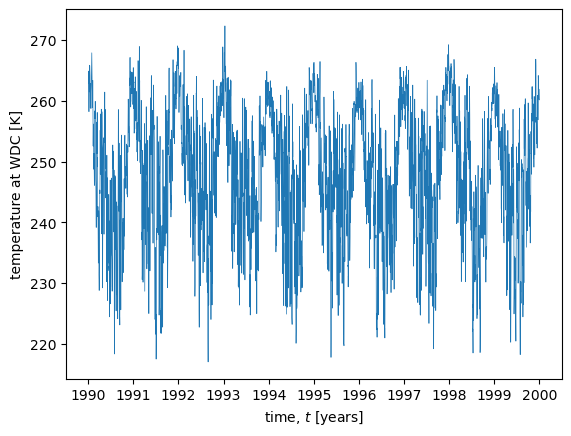

In [84]:
import matplotlib.pyplot as plt
plt.plot(time, T_WDC_2, linewidth = 0.5)
plt.xlabel('time, $t$ [years]');
plt.ylabel('temperature at WDC [K]');

In [85]:
SMB_WDC = SMB[Iy,Ix,:]
Xq = 0.0
Yq = 0.0
Ix = np.argmin(np.abs(Xq - X))
Iy = np.argmin(np.abs(Yq - Y))
SMB_SP = SMB[Iy,Ix,:]
T_SP = T[Iy,Ix,:]

Text(0, 0.5, 'temp at south pole [K]')

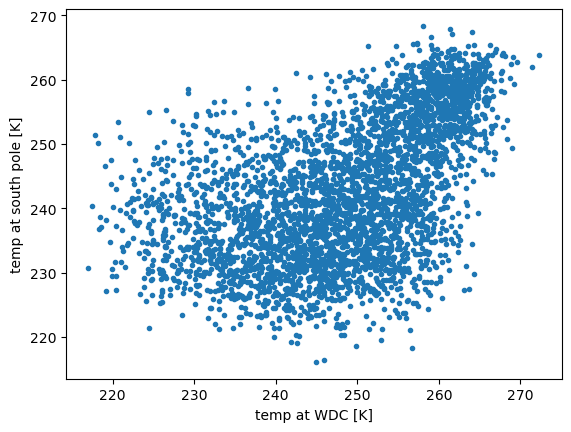

In [86]:
plt.plot(T_WDC,T_SP,'.')
plt.xlabel('temp at WDC [K]')
plt.ylabel('temp at south pole [K]')